MAE : 105758.56
R²  : -0.7015

Future Revenue Forecast
                 Date  Predicted_Revenue
2023-03-31 2024-01-31      372091.114350
2023-04-30 2024-02-29      201568.963049
2023-05-31 2024-03-31      282612.311335
2023-06-30 2024-04-30      269236.775933
2023-07-31 2024-05-31      353989.536497
2023-08-31 2024-06-30      199722.046945
2023-09-30 2024-07-31      198905.789600
2023-10-31 2024-08-31      377815.978044
2023-11-30 2024-09-30      285295.615188
2023-12-31 2024-10-31      258766.007099
2024-01-31 2024-11-30      235468.326208
2024-02-29 2024-12-31      295112.881085


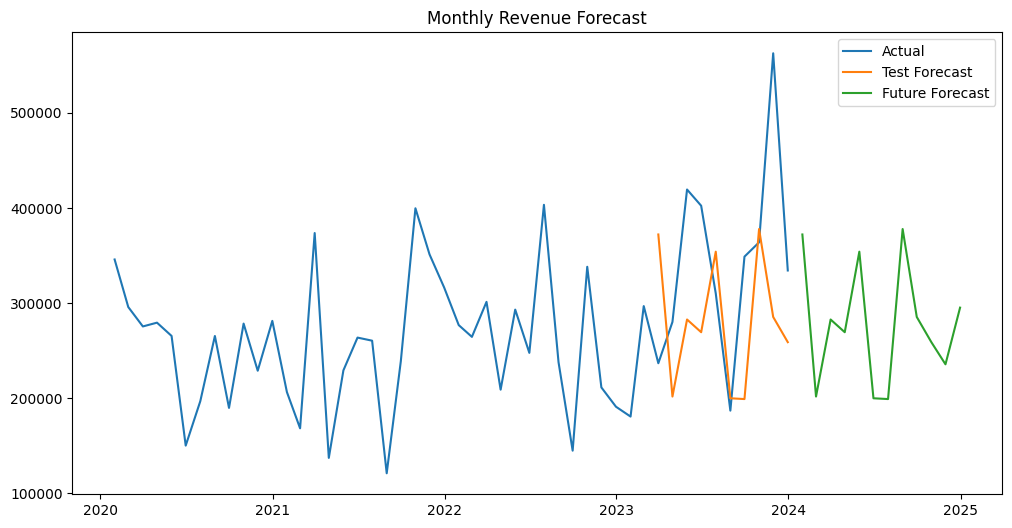

In [16]:
# ==========================================
# MONTHLY REVENUE FORECAST - SARIMA
# ==========================================

import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# Load Dataset
df = pd.read_csv("/kaggle/input/datasets/abhinavdubey0000/a-shop-ai/arima_ready_dataset.csv")

# Date Conversion
df["Date"] = pd.to_datetime(df["Date"])

# Monthly Revenue
monthly_revenue = (
    df.groupby(pd.Grouper(key="Date", freq="M"))["Total Amount"]
    .sum()
    .reset_index()
)

monthly_revenue.set_index("Date", inplace=True)

# Train Test Split
train_size = int(len(monthly_revenue) * 0.8)

train = monthly_revenue.iloc[:train_size]
test = monthly_revenue.iloc[train_size:]

# SARIMA Model
model = SARIMAX(
    train["Total Amount"],
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = model.fit()

# Predictions
pred = results.forecast(len(test))

# Metrics
mae = mean_absolute_error(test["Total Amount"], pred)
r2 = r2_score(test["Total Amount"], pred)

print(f"MAE : {mae:.2f}")
print(f"R²  : {r2:.4f}")

# Future Forecast
future_months = 12

future_forecast = results.forecast(future_months)

future_dates = pd.date_range(
    monthly_revenue.index[-1] + pd.offsets.MonthEnd(1),
    periods=future_months,
    freq="M"
)

forecast_df = pd.DataFrame({
    "Date": future_dates,
    "Predicted_Revenue": future_forecast
})

print("\nFuture Revenue Forecast")
print(forecast_df)

# Plot
plt.figure(figsize=(12,6))
plt.plot(monthly_revenue.index,
         monthly_revenue["Total Amount"],
         label="Actual")

plt.plot(test.index,
         pred,
         label="Test Forecast")

plt.plot(future_dates,
         future_forecast,
         label="Future Forecast")

plt.legend()
plt.title("Monthly Revenue Forecast")
plt.show()